In [1]:
import numpy as np

n_air = 1.00
n_pmma = 1.49  # UV-transmissive optical-grade cast acrylic at 365nm
# Source: confirm from supplier datasheet

critical_angle_rad = np.arcsin(n_air / n_pmma)
critical_angle_deg = np.degrees(critical_angle_rad)

print(f"n_PMMA at 365nm: {n_pmma}")
print(f"Critical angle: {critical_angle_deg:.2f} degrees")

n_PMMA at 365nm: 1.49
Critical angle: 42.16 degrees


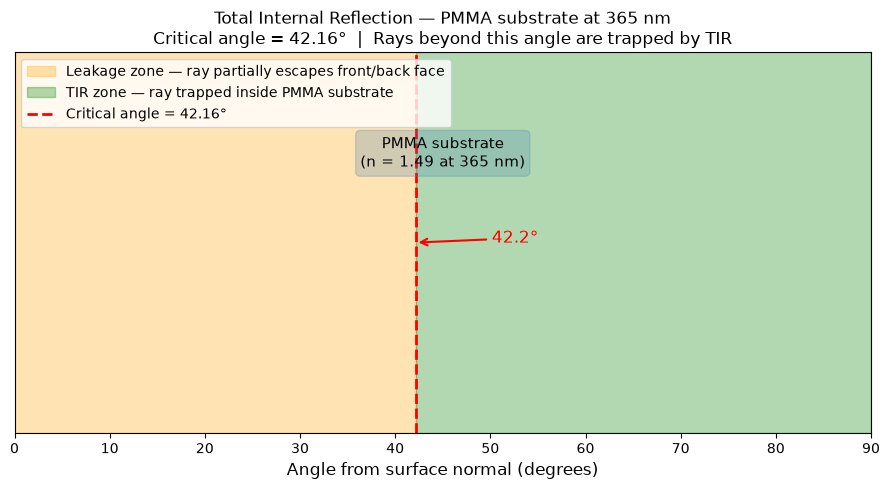

Critical angle: 42.16 degrees
Saved to outputs/tir_critical_angle.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)

n_air = 1.00
n_pmma = 1.49

critical_angle_rad = np.arcsin(n_air / n_pmma)
critical_angle_deg = np.degrees(critical_angle_rad)

fig, ax = plt.subplots(figsize=(9, 5))

# Leakage zone (left)
ax.axvspan(0, critical_angle_deg, alpha=0.3, color='orange',
           label='Leakage zone — ray partially escapes front/back face')

# TIR zone (right)
ax.axvspan(critical_angle_deg, 90, alpha=0.3, color='green',
           label='TIR zone — ray trapped inside PMMA substrate')

# Critical angle line
ax.axvline(x=critical_angle_deg, color='red', linewidth=2,
           linestyle='--', label=f'Critical angle = {critical_angle_deg:.2f}°')

# Substrate label as text box
ax.text(45, 0.7, 'PMMA substrate\n(n = 1.49 at 365 nm)',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='steelblue',
                  alpha=0.25, edgecolor='steelblue'))

# Annotate the critical angle value
ax.annotate(f'{critical_angle_deg:.1f}°',
            xy=(critical_angle_deg, 0.5),
            xytext=(critical_angle_deg + 8, 0.5),
            fontsize=12, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlim(0, 90)
ax.set_ylim(0, 1)
ax.set_xlabel('Angle from surface normal (degrees)', fontsize=12)
ax.set_title('Total Internal Reflection — PMMA substrate at 365 nm\n'
             f'Critical angle = {critical_angle_deg:.2f}°  |  '
             f'Rays beyond this angle are trapped by TIR', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.set_yticks([])

plt.tight_layout()
plt.savefig('outputs/tir_critical_angle.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Critical angle: {critical_angle_deg:.2f} degrees")
print("Saved to outputs/tir_critical_angle.png")